In [1]:
import os
import glob
import matplotlib.pyplot as plt
from PIL import Image
from keras import __version__
from keras.applications import MobileNet
from keras.applications.mobilenet import preprocess_input
from keras.models import Model
from keras.layers import Dense, GlobalAveragePooling2D
from keras.preprocessing.image import ImageDataGenerator
from keras.optimizers import Adam, SGD
from keras.models import Sequential
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
import numpy as np


In [1]:
import psutil

# Get the current CPU affinity for your process
current_affinity = psutil.Process().cpu_affinity()

# Display the current CPU affinity
print("Current CPU Affinity:", current_affinity)

Current CPU Affinity: [0, 1, 2, 3, 4, 5, 6, 7]


In [3]:
dataset_folder = "D:\\DatasetNew" 

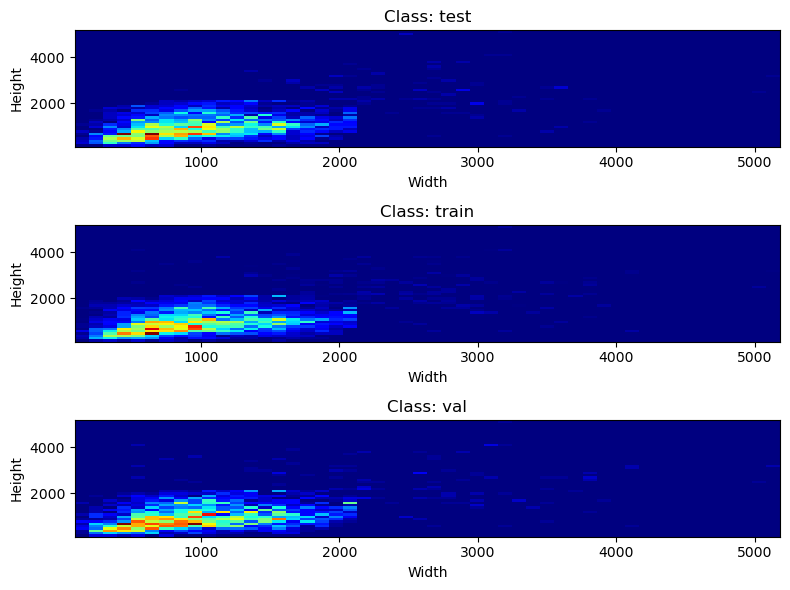

In [4]:
from PIL import Image
import os
import matplotlib.pyplot as plt

def plot_image_shapes(dataset_folder):
    class_shapes = {}

    for class_folder in os.listdir(dataset_folder):
        class_path = os.path.join(dataset_folder, class_folder)
        if os.path.isdir(class_path):
            class_shapes[class_folder] = []
            for snake_folder in os.listdir(class_path):
                snake_path = os.path.join(class_path, snake_folder)
                if os.path.isdir(snake_path):
                    for filename in os.listdir(snake_path):
                        if filename.endswith(('.png', '.jpg', '.jpeg')):
                            image_path = os.path.join(snake_path, filename)
                            with Image.open(image_path) as img:
                                width, height = img.size
                                class_shapes[class_folder].append((width, height))

    # Plotting
    fig, axes = plt.subplots(nrows=len(class_shapes), ncols=1, figsize=(8, 6))
    for i, (class_name, shapes) in enumerate(class_shapes.items()):
        axes[i].hist2d([w for w, _ in shapes], [h for _, h in shapes], bins=(50, 50), cmap=plt.cm.jet)
        axes[i].set_title(f"Class: {class_name}")
        axes[i].set_xlabel("Width")
        axes[i].set_ylabel("Height")

    plt.tight_layout()
    plt.show()


plot_image_shapes(dataset_folder)


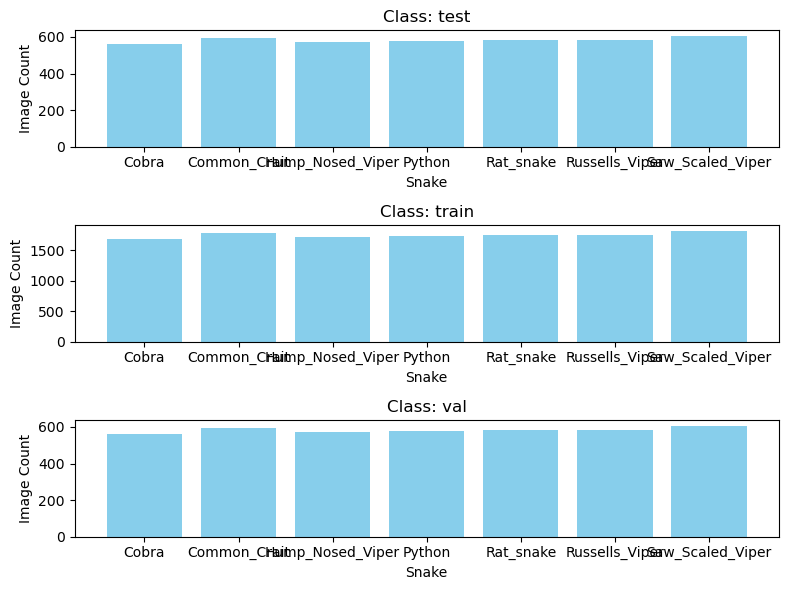

In [5]:
def plot_image_counts(dataset_folder):
    class_counts = {}

    for class_folder in os.listdir(dataset_folder):
        class_path = os.path.join(dataset_folder, class_folder)
        if os.path.isdir(class_path):
            class_counts[class_folder] = []
            for snake_folder in os.listdir(class_path):
                snake_path = os.path.join(class_path, snake_folder)
                if os.path.isdir(snake_path):
                    image_count = len([f for f in os.listdir(snake_path) if f.endswith(('.png', '.jpg', '.jpeg'))])
                    class_counts[class_folder].append((snake_folder, image_count))

    # Plotting
    fig, axes = plt.subplots(nrows=len(class_counts), ncols=1, figsize=(8, 6))
    for i, (class_name, counts) in enumerate(class_counts.items()):
        snakes, image_counts = zip(*counts)
        axes[i].bar(snakes, image_counts, color='skyblue')
        axes[i].set_title(f"Class: {class_name}")
        axes[i].set_xlabel("Snake")
        axes[i].set_ylabel("Image Count")

    plt.tight_layout()
    plt.show()

plot_image_counts(dataset_folder)

Found 12252 images belonging to 7 classes.
Found 4084 images belonging to 7 classes.



Epoch 1/3


382/382 [==============================] - 763s 2s/step - loss: 0.7535 - accuracy: 0.7304 - val_loss: 0.3545 - val_accuracy: 0.8848
Epoch 2/3
382/382 [==============================] - 693s 2s/step - loss: 0.4283 - accuracy: 0.8493 - val_loss: 0.2788 - val_accuracy: 0.9043
Epoch 3/3
382/382 [==============================] - 688s 2s/step - loss: 0.3431 - accuracy: 0.8818 - val_loss: 0.2303 - val_accuracy: 0.9181
Epoch 1/3
382/382 [==============================] - 913s 2s/step - loss: 0.4711 - accuracy: 0.8341 - val_loss: 0.2263 - val_accuracy: 0.9225
Epoch 2/3
382/382 [==============================] - 955s 3s/step - loss: 0.3364 - accuracy: 0.8817 - val_loss: 0.1796 - val_accuracy: 0.9392
Epoch 3/3
382/382 [==============================] - 925s 2s/step - loss: 0.2979 - accuracy: 0.8932 - val_loss: 0.1620 - val_accuracy: 0.9441
INFO:tensorflow:Assets written to: mobilenet-ft.model\asse

INFO:tensorflow:Assets written to: mobilenet-ft.model\assets


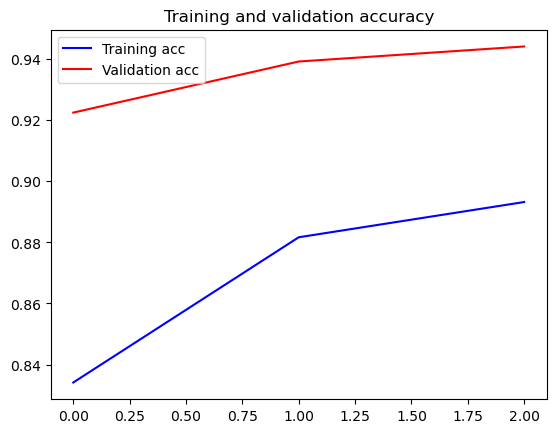

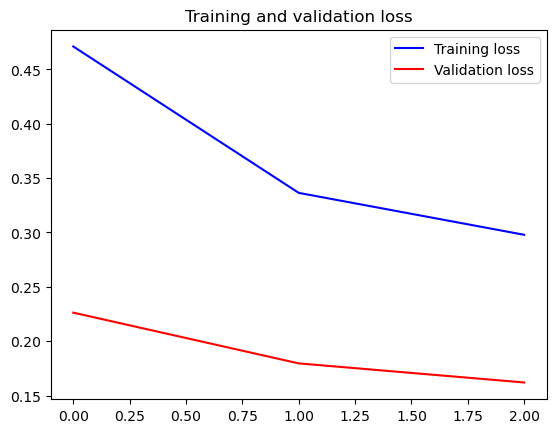

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv1 (Conv2D)              (None, 112, 112, 32)      864       
                                                                 
 conv1_bn (BatchNormalizati  (None, 112, 112, 32)      128       
 on)                                                             
                                                                 
 conv1_relu (ReLU)           (None, 112, 112, 32)      0         
                                                                 
 conv_dw_1 (DepthwiseConv2D  (None, 112, 112, 32)      288       
 )                                                               
                                                                 
 conv_dw_1_bn (BatchNormali  (None, 112, 112, 32)      128   

 )                                                               
                                                                 
 conv_dw_8_bn (BatchNormali  (None, 14, 14, 512)       2048      
 zation)                                                         
                                                                 
 conv_dw_8_relu (ReLU)       (None, 14, 14, 512)       0         
                                                                 
 conv_pw_8 (Conv2D)          (None, 14, 14, 512)       262144    
                                                                 
 conv_pw_8_bn (BatchNormali  (None, 14, 14, 512)       2048      
 zation)                                                         
                                                                 
 conv_pw_8_relu (ReLU)       (None, 14, 14, 512)       0         
                                                                 
 conv_dw_9 (DepthwiseConv2D  (None, 14, 14, 512)       4608      
 )        

In [6]:
from keras.applications.mobilenet import MobileNet, preprocess_input
from keras.preprocessing.image import ImageDataGenerator
from keras.layers import Dropout

IM_WIDTH, IM_HEIGHT = 224, 224
NB_EPOCHS = 3
BAT_SIZE = 32
FC_SIZE = 128
NB_MN_LAYERS_TO_FREEZE = 20
train_dir = "D:\\DatasetNew\\train"
val_dir = "D:\\DatasetNew\\val"
test_dir = "D:\\DatasetNew\\test"

def get_nb_files(directory):
    count = 0
    for root, dirs, files in os.walk(directory):
        count += len(files)
    return count

def add_new_last_layer_mobilenet(base_model, nb_classes, dropout_rate=0.5):
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(FC_SIZE, activation='relu')(x)
    x = Dropout(dropout_rate)(x)  # Add dropout layer
    predictions = Dense(nb_classes, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=predictions)
    return model

def setup_to_transfer_learn_mobilenet(model, base_model):
    for layer in base_model.layers:
        layer.trainable = False
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

def setup_to_finetune_mobilenet(model):
    for layer in model.layers[:NB_MN_LAYERS_TO_FREEZE]:
        layer.trainable = False
    for layer in model.layers[NB_MN_LAYERS_TO_FREEZE:]:
        layer.trainable = True
    model.compile(optimizer=SGD(learning_rate=0.0001, momentum=0.9), loss='categorical_crossentropy', metrics=['accuracy'])

def plot_training(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(len(acc))

    plt.plot(epochs, acc, 'b', label='Training acc')
    plt.plot(epochs, val_acc, 'r', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.figure()

    plt.plot(epochs, loss, 'b', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

    plt.show()

def train_mobilenet(train_dir, val_dir, nb_epoch=NB_EPOCHS, batch_size=BAT_SIZE, output_model_file="mobilenet-ft.model", plot=True):
    nb_train_samples = get_nb_files(train_dir)
    nb_classes = len(glob.glob(train_dir + "/*"))
    nb_val_samples = get_nb_files(val_dir)

    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True
        # Filling strategy for rotated images
    )

    val_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True
    )
    
    train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(IM_WIDTH, IM_HEIGHT),
        batch_size=batch_size,
        class_mode='categorical'
    )

    validation_generator = val_datagen.flow_from_directory(
        val_dir,
        target_size=(IM_WIDTH, IM_HEIGHT),
        batch_size=batch_size,
        class_mode='categorical'
    )

    base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(IM_WIDTH, IM_HEIGHT, 3))
    model = add_new_last_layer_mobilenet(base_model, nb_classes)

    setup_to_transfer_learn_mobilenet(model, base_model)

    history_tl = model.fit(
        train_generator,
        epochs=nb_epoch,
        steps_per_epoch=nb_train_samples // batch_size,
        validation_data=validation_generator,
        validation_steps=nb_val_samples // batch_size,
        
    )

    setup_to_finetune_mobilenet(model)

    history_ft = model.fit(
        train_generator,
        steps_per_epoch=nb_train_samples // batch_size,
        epochs=nb_epoch,
        validation_data=validation_generator,
        validation_steps=nb_val_samples // batch_size,
        
    )

    model.save(output_model_file)

    if plot:
        plot_training(history_ft)

    return model

# Train the MobileNet model and get the trained model
trained_mobilenet_model = train_mobilenet(train_dir=train_dir, val_dir=val_dir, nb_epoch=NB_EPOCHS, batch_size=BAT_SIZE, output_model_file="mobilenet-ft.model", plot=True)

# Display the model summary
trained_mobilenet_model.summary()

# resnet50v2

In [1]:
import os
import glob
import matplotlib.pyplot as plt
from keras.applications import ResNet50V2
from keras.applications.resnet_v2 import preprocess_input, decode_predictions
from keras.models import Model
from keras.layers import Dense, GlobalAveragePooling2D, Dropout
from keras.optimizers import SGD
from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from sklearn.model_selection import train_test_split

In [ ]:


IM_WIDTH, IM_HEIGHT = 224, 224
NB_EPOCHS = 3
BAT_SIZE = 32
FC_SIZE = 128
NB_RES_BLOCKS_TO_FREEZE = 4  # Number of blocks in stage 4
train_dir = "D:\\DatasetNew\\train"
val_dir = "D:\\DatasetNew\\val"
test_dir = "D:\\DatasetNew\\test"

def get_nb_files(directory):
    count = 0
    for root, dirs, files in os.walk(directory):
        count += len(files)
    return count


def add_new_last_layer_resnet50v2(base_model, nb_classes, dropout_rate=0.5):
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(FC_SIZE, activation='relu')(x)
    x = Dropout(dropout_rate)(x)  # Add dropout layer
    predictions = Dense(nb_classes, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=predictions)
    return model

def setup_to_transfer_learn_resnet50v2(model, base_model):
    for layer in base_model.layers:
        layer.trainable = False
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

def setup_to_finetune_resnet50v2(model):
    # Find the index of the last convolutional block in stage 4
    last_conv_block = f"conv{NB_RES_BLOCKS_TO_FREEZE}_block3_out"
    
    # Freeze layers up to the last convolutional block in stage 4
    for layer in model.get_layer('resnet50v2').layers:
        if layer.name == last_conv_block:
            break
        layer.trainable = False
    
    # Fine-tune layers from the last convolutional block in stage 4 onwards
    for layer in model.layers:
        if layer.name.startswith('conv5'):
            layer.trainable = True

    model.compile(optimizer=SGD(learning_rate=0.0001, momentum=0.9), loss='categorical_crossentropy', metrics=['accuracy'])

def train_resnet50v2(train_dir, val_dir, nb_epoch=NB_EPOCHS, batch_size=BAT_SIZE, output_model_file="resnet50v2-ft.model", plot=True):
    nb_train_samples = get_nb_files(train_dir)
    nb_classes = len(glob.glob(train_dir + "/*"))
    nb_val_samples = get_nb_files(val_dir)

    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True
    )

    val_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True
    )
    
    train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(IM_WIDTH, IM_HEIGHT),
        batch_size=batch_size,
        class_mode='categorical'
    )

    validation_generator = val_datagen.flow_from_directory(
        val_dir,
        target_size=(IM_WIDTH, IM_HEIGHT),
        batch_size=batch_size,
        class_mode='categorical'
    )

    base_model = ResNet50V2(weights='imagenet', include_top=False, input_shape=(IM_WIDTH, IM_HEIGHT, 3))
    model = add_new_last_layer_resnet50v2(base_model, nb_classes)

    setup_to_transfer_learn_resnet50v2(model, base_model)

    history_tl = model.fit(
        train_generator,
        epochs=nb_epoch,
        steps_per_epoch=nb_train_samples // batch_size,
        validation_data=validation_generator,
        validation_steps=nb_val_samples // batch_size,
    )

    setup_to_finetune_resnet50v2(model)

    history_ft = model.fit(
        train_generator,
        steps_per_epoch=nb_train_samples // batch_size,
        epochs=nb_epoch,
        validation_data=validation_generator,
        validation_steps=nb_val_samples // batch_size,
    )

    model.save(output_model_file)

    if plot:
        plot_training(history_ft)

    return model

# Train the ResNet50V2 model and get the trained model
trained_resnet50v2_model = train_resnet50v2(train_dir=train_dir, val_dir=val_dir, nb_epoch=NB_EPOCHS, batch_size=BAT_SIZE, output_model_file="resnet50v2-ft.model", plot=True)

# Display the model summary
trained_resnet50v2_model.summary()


Found 12112 images belonging to 7 classes.
Found 4084 images belonging to 7 classes.


94668760/94668760 [==============================] - 344s 4us/step

Epoch 1/3


378/378 [==============================] - 1336s 4s/step - loss: 0.7160 - accuracy: 0.7453 - val_loss: 0.3474 - val_accuracy: 0.8745
Epoch 2/3
 57/378 [===>..........................] - ETA: 10:45 - loss: 0.4819 - accuracy: 0.8279